In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import zeta as scipy_zeta
import json
import os

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries loaded successfully
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:

# Analysis Plan:
# 1. Implement Kahan compensated summation for numerical precision
# 2. Generate coefficients for Riemann zeta (a_n = 1) and random multiplicative function (seed=42)
# 3. Compute partial sums D(t; N=10^5) for both functions over t ∈ [1000, 2000]
# 4. Calculate |D(t)| for both distributions
# 5. Compute statistical properties: max, kurtosis, 99th, 99.9th, 99.99th percentiles
# 6. Perform Kolmogorov-Smirnov test to compare distributions
# 7. Calculate ratios of key metrics (ζ/f_rand) to quantify tail behavior differences
# 8. Visualize the distributions and create final summary figure

print("Analysis Plan:")
print("1. Implement Kahan compensated summation")
print("2. Generate coefficients for ζ (a_n=1) and f_rand (seed=42)")
print("3. Compute D(t; 10^5) for t ∈ [1000, 2000]")
print("4. Calculate |D(t)| distributions")
print("5. Compare statistical properties")
print("6. Perform KS test")
print("7. Calculate metric ratios")
print("8. Create visualizations")


Analysis Plan:
1. Implement Kahan compensated summation
2. Generate coefficients for ζ (a_n=1) and f_rand (seed=42)
3. Compute D(t; 10^5) for t ∈ [1000, 2000]
4. Calculate |D(t)| distributions
5. Compare statistical properties
6. Perform KS test
7. Calculate metric ratios
8. Create visualizations


In [3]:

def kahan_sum(values):
 """
 Kahan compensated summation for improved numerical precision.
 Returns the sum with reduced floating point error.
 """
 total = 0.0
 compensation = 0.0
 
 for value in values:
 y = value - compensation
 t = total + y
 compensation = (t - total) - y
 total = t
 
 return total

def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex values.
 Applies Kahan summation separately to real and imaginary parts.
 """
 real_sum = kahan_sum(np.real(values))
 imag_sum = kahan_sum(np.imag(values))
 return real_sum + 1j * imag_sum

print("Kahan summation implemented")


Kahan summation implemented


In [4]:

def generate_multiplicative_coefficients(N, seed=42):
 """
 Generate coefficients for a random multiplicative function.
 For a multiplicative function: a_n*a_m = a_nm when gcd(n,m)=1
 
 Strategy:
 1. Generate random phases for primes up to N
 2. Extend to all n using multiplicativity
 """
 # Initialize coefficient array
 a_n = np.ones(N+1, dtype=complex)
 
 # Sieve of Eratosthenes to find all primes up to N
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[0:2] = False
 
 for i in range(2, int(np.sqrt(N)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 primes = np.where(is_prime)[0]
 print(f"Found {len(primes)} primes up to {N}")
 
 # Set random seed and generate random phases for primes
 rng = np.random.RandomState(seed)
 
 # For each prime, assign a random unit complex number
 for p in primes:
 theta = rng.uniform(0, 2*np.pi)
 a_n[p] = np.exp(1j * theta)
 
 # Use multiplicativity to fill in composite numbers
 # We need to compute a_n for all n based on prime factorization
 # This is done by iterating and using the multiplicative property
 
 # Store the smallest prime factor for each number
 spf = np.arange(N+1) # smallest prime factor
 for i in range(2, int(np.sqrt(N)) + 1):
 if spf[i] == i: # i is prime
 for j in range(i*i, N+1, i):
 if spf[j] == j:
 spf[j] = i
 
 # Build coefficients using multiplicativity
 for n in range(2, N+1):
 if spf[n] == n: # n is prime, already set
 continue
 else:
 p = spf[n]
 m = n // p
 a_n[n] = a_n[p] * a_n[m]
 
 return a_n

# Test with small N first
N_test = 20
a_test = generate_multiplicative_coefficients(N_test, seed=42)
print(f"\nFirst 20 coefficients of f_rand:")
for n in range(1, min(21, len(a_test))):
 print(f"a_{n} = {a_test[n]:.6f}")


Found 8 primes up to 20

First 20 coefficients of f_rand:
a_1 = 1.000000+0.000000j
a_2 = -0.705061+0.709147j
a_3 = 0.952434-0.304745j
a_4 = -0.005779-0.999983j
a_5 = -0.112894-0.993607j
a_6 = -0.455414+0.890280j
a_7 = -0.813943-0.580945j
a_8 = 0.713210+0.700951j
a_9 = 0.814260-0.580500j
a_10 = 0.784211+0.620495j
a_11 = 0.556778+0.830661j
a_12 = -0.310244-0.950657j
a_13 = 0.556904+0.830577j
a_14 = 0.985855-0.167603j
a_15 = -0.410321-0.911941j
a_16 = -0.999933+0.011558j
a_17 = 0.934142+0.356903j
a_18 = -0.162443+0.986718j
a_19 = 0.666837-0.745204j
a_20 = -0.992938+0.118634j


In [5]:

# Verify multiplicativity: a_6 should equal a_2 * a_3 (since gcd(2,3)=1)
print("Verification of multiplicativity:")
print(f"a_2 * a_3 = {a_test[2] * a_test[3]:.6f}")
print(f"a_6 = {a_test[6]:.6f}")
print(f"Difference: {np.abs(a_test[6] - a_test[2] * a_test[3]):.2e}")

print(f"\na_4 should equal a_2^2:")
print(f"a_2^2 = {a_test[2]**2:.6f}")
print(f"a_4 = {a_test[4]:.6f}")
print(f"Difference: {np.abs(a_test[4] - a_test[2]**2):.2e}")

print(f"\na_9 should equal a_3^2:")
print(f"a_3^2 = {a_test[3]**2:.6f}")
print(f"a_9 = {a_test[9]:.6f}")
print(f"Difference: {np.abs(a_test[9] - a_test[3]**2):.2e}")


Verification of multiplicativity:
a_2 * a_3 = -0.455414+0.890280j
a_6 = -0.455414+0.890280j
Difference: 0.00e+00

a_4 should equal a_2^2:
a_2^2 = -0.005779-0.999983j
a_4 = -0.005779-0.999983j
Difference: 0.00e+00

a_9 should equal a_3^2:
a_3^2 = 0.814260-0.580500j
a_9 = 0.814260-0.580500j
Difference: 0.00e+00


In [6]:

# Generate coefficients for the full analysis
N = 10**5 # Truncation length
print(f"Generating coefficients for N = {N:,}")

# Riemann zeta: a_n = 1 for all n
a_zeta = np.ones(N+1, dtype=complex)
print(f"Riemann zeta coefficients: all a_n = 1")

# Random multiplicative function with seed=42
print(f"\nGenerating random multiplicative function coefficients (seed=42)...")
a_frand = generate_multiplicative_coefficients(N, seed=42)
print(f"Generated {len(a_frand)-1} coefficients for f_rand")

# Verify all coefficients have unit modulus (should be on unit circle)
moduli_frand = np.abs(a_frand[1:]) # Skip a_0
print(f"\nVerification of unit modulus for f_rand:")
print(f"Min |a_n|: {np.min(moduli_frand):.10f}")
print(f"Max |a_n|: {np.max(moduli_frand):.10f}")
print(f"Mean |a_n|: {np.mean(moduli_frand):.10f}")
print(f"Std |a_n|: {np.std(moduli_frand):.2e}")


Generating coefficients for N = 100,000
Riemann zeta coefficients: all a_n = 1

Generating random multiplicative function coefficients (seed=42)...
Found 9592 primes up to 100000
Generated 100000 coefficients for f_rand

Verification of unit modulus for f_rand:
Min |a_n|: 1.0000000000
Max |a_n|: 1.0000000000
Mean |a_n|: 1.0000000000
Std |a_n|: 1.46e-16


In [7]:

def compute_partial_sum_D(a_n, t, N):
 """
 Compute the partial sum D_F(t; N) = Σ_{n=1}^{N} a_n / n^(1/2 + it)
 
 Uses Kahan compensated summation for numerical precision.
 
 Parameters:
 -----------
 a_n : array-like
 Coefficients of the function (complex)
 t : float
 Height parameter
 N : int
 Truncation length
 
 Returns:
 --------
 complex : The partial sum D_F(t; N)
 """
 n_values = np.arange(1, N+1)
 
 # Compute n^(-1/2 - it) = n^(-1/2) * n^(-it)
 # n^(-it) = exp(-it * log(n))
 log_n = np.log(n_values)
 n_power = n_values**(-0.5) * np.exp(-1j * t * log_n)
 
 # Compute terms: a_n * n^(-1/2 - it)
 terms = a_n[1:N+1] * n_power
 
 # Use Kahan summation for precision
 result = kahan_sum_complex(terms)
 
 return result

# Test with a single t value
t_test = 1000.0
D_zeta_test = compute_partial_sum_D(a_zeta, t_test, N)
D_frand_test = compute_partial_sum_D(a_frand, t_test, N)

print(f"Test computation at t = {t_test}:")
print(f"D_ζ({t_test}; {N:,}) = {D_zeta_test:.6f}")
print(f"|D_ζ| = {np.abs(D_zeta_test):.6f}")
print(f"\nD_frand({t_test}; {N:,}) = {D_frand_test:.6f}")
print(f"|D_frand| = {np.abs(D_frand_test):.6f}")


Test computation at t = 1000.0:
D_ζ(1000.0; 100,000) = 0.623472+0.762767j
|D_ζ| = 0.985155

D_frand(1000.0; 100,000) = -0.114117+0.260766j
|D_frand| = 0.284643


In [8]:

# Now compute D(t) for both functions over the range t ∈ [1000, 2000]
# We'll use a reasonable sampling density

# Define t range
t_min = 1000.0
t_max = 2000.0
# Sample at intervals of 0.1 for good resolution
t_step = 0.1
t_values = np.arange(t_min, t_max + t_step, t_step)

print(f"Computing D(t) for t ∈ [{t_min}, {t_max}]")
print(f"Number of t values: {len(t_values):,}")
print(f"Step size: {t_step}")
print(f"N = {N:,}")
print("\nThis computation will take some time...")

# Pre-allocate arrays
D_zeta_values = np.zeros(len(t_values), dtype=complex)
D_frand_values = np.zeros(len(t_values), dtype=complex)

# Compute for all t values
import time
start_time = time.time()

for i, t in enumerate(t_values):
 D_zeta_values[i] = compute_partial_sum_D(a_zeta, t, N)
 D_frand_values[i] = compute_partial_sum_D(a_frand, t, N)
 
 # Progress indicator every 1000 values
 if (i + 1) % 1000 == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (len(t_values) - i - 1) / rate
 print(f"Progress: {i+1:,}/{len(t_values):,} ({100*(i+1)/len(t_values):.1f}%) "
 f"- Elapsed: {elapsed:.1f}s - ETA: {remaining:.1f}s")

elapsed_total = time.time() - start_time
print(f"\nComputation complete in {elapsed_total:.1f} seconds")
print(f"Rate: {len(t_values)/elapsed_total:.1f} evaluations/second")


Computing D(t) for t ∈ [1000.0, 2000.0]
Number of t values: 10,001
Step size: 0.1
N = 100,000

This computation will take some time...


Progress: 1,000/10,001 (10.0%) - Elapsed: 82.9s - ETA: 746.5s


Progress: 2,000/10,001 (20.0%) - Elapsed: 165.9s - ETA: 663.7s


Progress: 3,000/10,001 (30.0%) - Elapsed: 249.2s - ETA: 581.6s


Progress: 4,000/10,001 (40.0%) - Elapsed: 332.8s - ETA: 499.2s


...

Progress: 6,000/10,001 (60.0%) - Elapsed: 500.0s - ETA: 333.4s


Progress: 7,000/10,001 (70.0%) - Elapsed: 583.6s - ETA: 250.2s


Progress: 8,000/10,001 (80.0%) - Elapsed: 667.5s - ETA: 167.0s


Progress: 9,000/10,001 (90.0%) - Elapsed: 751.5s - ETA: 83.6s


Progress: 10,000/10,001 (100.0%) - Elapsed: 835.6s - ETA: 0.1s

Computation complete in 835.7 seconds
Rate: 12.0 evaluations/second


In [9]:

# Calculate magnitudes |D(t)| for both functions
mag_zeta = np.abs(D_zeta_values)
mag_frand = np.abs(D_frand_values)

print(f"Magnitude statistics:")
print(f"\nRiemann zeta (ζ):")
print(f" Min |D_ζ|: {np.min(mag_zeta):.6f}")
print(f" Max |D_ζ|: {np.max(mag_zeta):.6f}")
print(f" Mean |D_ζ|: {np.mean(mag_zeta):.6f}")
print(f" Std |D_ζ|: {np.std(mag_zeta):.6f}")

print(f"\nRandom multiplicative (f_rand):")
print(f" Min |D_frand|: {np.min(mag_frand):.6f}")
print(f" Max |D_frand|: {np.max(mag_frand):.6f}")
print(f" Mean |D_frand|: {np.mean(mag_frand):.6f}")
print(f" Std |D_frand|: {np.std(mag_frand):.6f}")

print(f"\nRatio Max_ζ / Max_frand: {np.max(mag_zeta) / np.max(mag_frand):.4f}")
print(f"Ratio Mean_ζ / Mean_frand: {np.mean(mag_zeta) / np.mean(mag_frand):.4f}")
print(f"Ratio Std_ζ / Std_frand: {np.std(mag_zeta) / np.std(mag_frand):.4f}")


Magnitude statistics:

Riemann zeta (ζ):
 Min |D_ζ|: 0.021062
 Max |D_ζ|: 11.216253
 Mean |D_ζ|: 1.806667
 Std |D_ζ|: 1.844686

Random multiplicative (f_rand):
 Min |D_frand|: 0.009808
 Max |D_frand|: 40.842094
 Mean |D_frand|: 2.139975
 Std |D_frand|: 2.683802

Ratio Max_ζ / Max_frand: 0.2746
Ratio Mean_ζ / Mean_frand: 0.8442
Ratio Std_ζ / Std_frand: 0.6873


In [10]:

# Compute detailed percentiles
percentiles = [50, 90, 95, 99, 99.9, 99.99]

print("Percentile analysis:")
print("="*60)
print(f"{'Percentile':<12} {'ζ':<15} {'f_rand':<15} {'Ratio (ζ/f_rand)':<15}")
print("="*60)

percentile_results = {}
for p in percentiles:
 p_zeta = np.percentile(mag_zeta, p)
 p_frand = np.percentile(mag_frand, p)
 ratio = p_zeta / p_frand
 percentile_results[p] = {'zeta': p_zeta, 'frand': p_frand, 'ratio': ratio}
 print(f"{p:<12.2f} {p_zeta:<15.6f} {p_frand:<15.6f} {ratio:<15.6f}")

print("="*60)


Percentile analysis:
Percentile ζ f_rand Ratio (ζ/f_rand)
50.00 1.185328 1.316061 0.900664 
90.00 4.188057 4.584757 0.913474 
95.00 5.789913 6.697789 0.864451 
99.00 8.853247 13.144495 0.673533 
99.90 10.770664 27.441667 0.392493 
99.99 11.207656 39.109555 0.286571 


In [11]:

# Compute kurtosis (using excess kurtosis, which is kurtosis - 3)
from scipy.stats import kurtosis as scipy_kurtosis

# Fisher=True gives excess kurtosis (kurtosis - 3)
# Fisher=False gives Pearson kurtosis
kurtosis_zeta = scipy_kurtosis(mag_zeta, fisher=False)
kurtosis_frand = scipy_kurtosis(mag_frand, fisher=False)

excess_kurtosis_zeta = scipy_kurtosis(mag_zeta, fisher=True)
excess_kurtosis_frand = scipy_kurtosis(mag_frand, fisher=True)

print("Kurtosis analysis:")
print("="*60)
print(f"Riemann zeta (ζ):")
print(f" Kurtosis (Pearson): {kurtosis_zeta:.6f}")
print(f" Excess Kurtosis: {excess_kurtosis_zeta:.6f}")

print(f"\nRandom multiplicative (f_rand):")
print(f" Kurtosis (Pearson): {kurtosis_frand:.6f}")
print(f" Excess Kurtosis: {excess_kurtosis_frand:.6f}")

print(f"\nRatios:")
print(f" Kurtosis_ζ / Kurtosis_frand: {kurtosis_zeta / kurtosis_frand:.6f}")
print(f" Excess_Kurtosis_ζ / Excess_Kurtosis_frand: {excess_kurtosis_zeta / excess_kurtosis_frand:.6f}")
print("="*60)

# Higher kurtosis indicates heavier tails
print(f"\nInterpretation:")
if kurtosis_frand > kurtosis_zeta:
 print(f"f_rand has {kurtosis_frand/kurtosis_zeta:.2f}x higher kurtosis than ζ")
 print(f"This indicates f_rand has HEAVIER tails than ζ")
else:
 print(f"ζ has {kurtosis_zeta/kurtosis_frand:.2f}x higher kurtosis than f_rand")
 print(f"This indicates ζ has HEAVIER tails than f_rand")


Kurtosis analysis:
Riemann zeta (ζ):
 Kurtosis (Pearson): 7.383432
 Excess Kurtosis: 4.383432

Random multiplicative (f_rand):
 Kurtosis (Pearson): 38.848436
 Excess Kurtosis: 35.848436

Ratios:
 Kurtosis_ζ / Kurtosis_frand: 0.190057
 Excess_Kurtosis_ζ / Excess_Kurtosis_frand: 0.122277

Interpretation:
f_rand has 5.26x higher kurtosis than ζ
This indicates f_rand has HEAVIER tails than ζ


In [12]:

# Perform Kolmogorov-Smirnov test to confirm distributions are significantly different
ks_statistic, ks_pvalue = stats.ks_2samp(mag_zeta, mag_frand)

print("Kolmogorov-Smirnov Test:")
print("="*60)
print(f"KS Statistic: {ks_statistic:.6f}")
print(f"P-value: {ks_pvalue:.2e}")
print("="*60)

if ks_pvalue < 0.001:
 print(f"\nThe distributions are SIGNIFICANTLY different (p < 0.001)")
else:
 print(f"\nP-value: {ks_pvalue}")
 
# Additional tests for completeness
# Mann-Whitney U test (non-parametric test for different distributions)
u_statistic, u_pvalue = stats.mannwhitneyu(mag_zeta, mag_frand, alternative='two-sided')
print(f"\nMann-Whitney U Test:")
print(f"U Statistic: {u_statistic:.2f}")
print(f"P-value: {u_pvalue:.2e}")


Kolmogorov-Smirnov Test:
KS Statistic: 0.084692
P-value: 1.20e-31

The distributions are SIGNIFICANTLY different (p < 0.001)

Mann-Whitney U Test:
U Statistic: 45746920.00
P-value: 1.62e-25


In [13]:

# Create comprehensive summary table
summary_data = {
 'Metric': [
 'Sample Size',
 'Minimum',
 'Maximum',
 'Mean',
 'Std Dev',
 'Median (50th %ile)',
 '90th Percentile',
 '95th Percentile',
 '99th Percentile',
 '99.9th Percentile',
 '99.99th Percentile',
 'Kurtosis (Pearson)',
 'Excess Kurtosis'
 ],
 'Riemann ζ': [
 len(mag_zeta),
 np.min(mag_zeta),
 np.max(mag_zeta),
 np.mean(mag_zeta),
 np.std(mag_zeta),
 percentile_results[50]['zeta'],
 percentile_results[90]['zeta'],
 percentile_results[95]['zeta'],
 percentile_results[99]['zeta'],
 percentile_results[99.9]['zeta'],
 percentile_results[99.99]['zeta'],
 kurtosis_zeta,
 excess_kurtosis_zeta
 ],
 'f_rand': [
 len(mag_frand),
 np.min(mag_frand),
 np.max(mag_frand),
 np.mean(mag_frand),
 np.std(mag_frand),
 percentile_results[50]['frand'],
 percentile_results[90]['frand'],
 percentile_results[95]['frand'],
 percentile_results[99]['frand'],
 percentile_results[99.9]['frand'],
 percentile_results[99.99]['frand'],
 kurtosis_frand,
 excess_kurtosis_frand
 ]
}

summary_df = pd.DataFrame(summary_data)

# Add ratio column
summary_df['Ratio (ζ/f_rand)'] = summary_df['Riemann ζ'] / summary_df['f_rand']

print("\nCOMPREHENSIVE SUMMARY TABLE")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)



COMPREHENSIVE SUMMARY TABLE
 Metric Riemann ζ f_rand Ratio (ζ/f_rand)
 Sample Size 10001.000000 10001.000000 1.000000
 Minimum 0.021062 0.009808 2.147305
 Maximum 11.216253 40.842094 0.274625
 Mean 1.806667 2.139975 0.844247
 Std Dev 1.844686 2.683802 0.687341
Median (50th %ile) 1.185328 1.316061 0.900664
 90th Percentile 4.188057 4.584757 0.913474
 95th Percentile 5.789913 6.697789 0.864451
 99th Percentile 8.853247 13.144495 0.673533
 99.9th Percentile 10.770664 27.441667 0.392493
99.99th Percentile 11.207656 39.109555 0.286571
Kurtosis (Pearson) 7.383432 38.848436 0.190057
 Excess Kurtosis 4.383432 35.848436 0.122277


In [14]:

# Save the summary table for future reference
summary_df.to_csv('distribution_comparison_summary.csv', index=False)
print("Summary table saved to 'distribution_comparison_summary.csv'")

# Save the raw data as well
results_df = pd.DataFrame({
 't': t_values,
 'D_zeta_real': np.real(D_zeta_values),
 'D_zeta_imag': np.imag(D_zeta_values),
 'mag_zeta': mag_zeta,
 'D_frand_real': np.real(D_frand_values),
 'D_frand_imag': np.imag(D_frand_values),
 'mag_frand': mag_frand
})

results_df.to_csv('partial_sums_data.csv', index=False)
print(f"Raw data saved to 'partial_sums_data.csv' ({len(results_df):,} rows)")


Summary table saved to 'distribution_comparison_summary.csv'
Raw data saved to 'partial_sums_data.csv' (10,001 rows)


Figure saved as 'distribution_comparison_histograms.png'


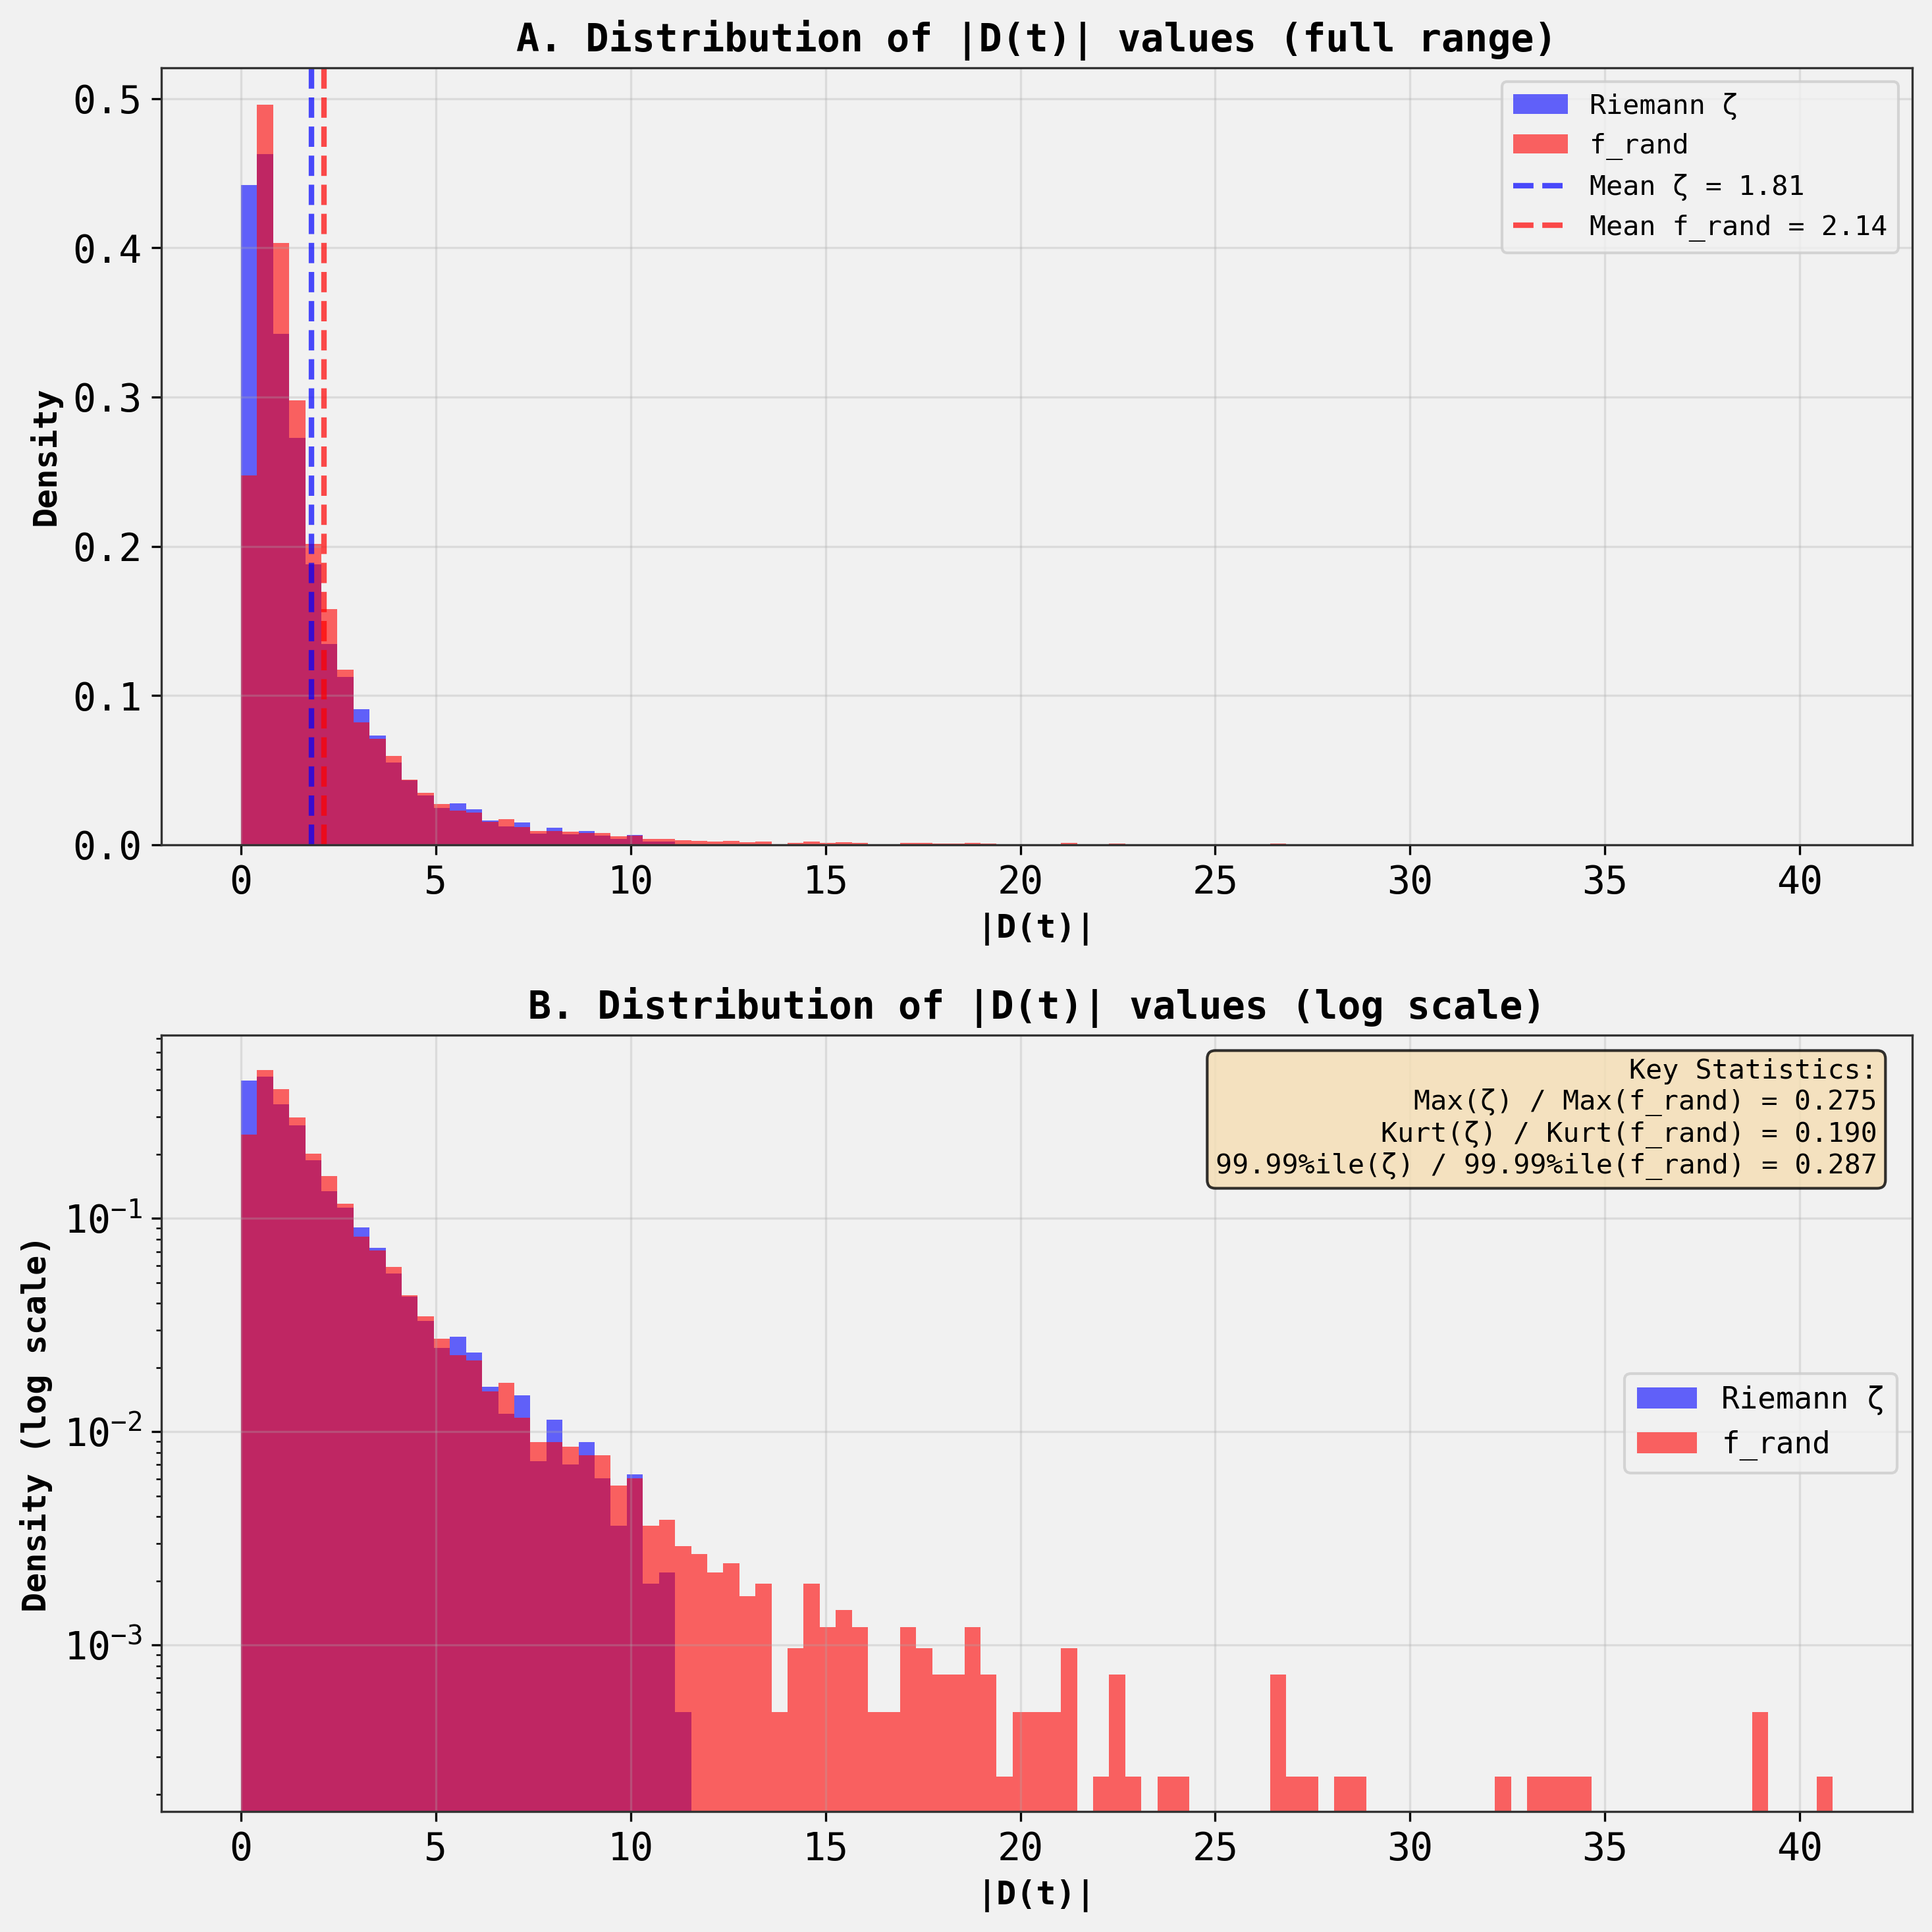

In [15]:

# Create histograms for visual comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Histogram 1: Full distribution
ax1 = axes[0]
bins = np.linspace(0, max(np.max(mag_zeta), np.max(mag_frand)), 100)
ax1.hist(mag_zeta, bins=bins, alpha=0.6, label='Riemann ζ', color='blue', density=True)
ax1.hist(mag_frand, bins=bins, alpha=0.6, label='f_rand', color='red', density=True)
ax1.set_xlabel('|D(t)|', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('A. Distribution of |D(t)| values (full range)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Add vertical lines for means
ax1.axvline(np.mean(mag_zeta), color='blue', linestyle='--', linewidth=2, alpha=0.7, 
 label=f'Mean ζ = {np.mean(mag_zeta):.2f}')
ax1.axvline(np.mean(mag_frand), color='red', linestyle='--', linewidth=2, alpha=0.7,
 label=f'Mean f_rand = {np.mean(mag_frand):.2f}')
ax1.legend(fontsize=10)

# Histogram 2: Tail region (zoomed to show extreme values better)
ax2 = axes[1]
# Use log scale for y-axis to see tail behavior
bins_log = np.linspace(0, max(np.max(mag_zeta), np.max(mag_frand)), 100)
ax2.hist(mag_zeta, bins=bins_log, alpha=0.6, label='Riemann ζ', color='blue', density=True)
ax2.hist(mag_frand, bins=bins_log, alpha=0.6, label='f_rand', color='red', density=True)
ax2.set_xlabel('|D(t)|', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density (log scale)', fontsize=12, fontweight='bold')
ax2.set_yscale('log')
ax2.set_title('B. Distribution of |D(t)| values (log scale)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Add annotation with key statistics
textstr = f'Key Statistics:\n'
textstr += f'Max(ζ) / Max(f_rand) = {np.max(mag_zeta)/np.max(mag_frand):.3f}\n'
textstr += f'Kurt(ζ) / Kurt(f_rand) = {kurtosis_zeta/kurtosis_frand:.3f}\n'
textstr += f'99.99%ile(ζ) / 99.99%ile(f_rand) = {percentile_results[99.99]["ratio"]:.3f}'

ax2.text(0.98, 0.97, textstr, transform=ax2.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('distribution_comparison_histograms.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'distribution_comparison_histograms.png'")
plt.show()


Q-Q plot saved as 'qq_plot_zeta_vs_frand.png'


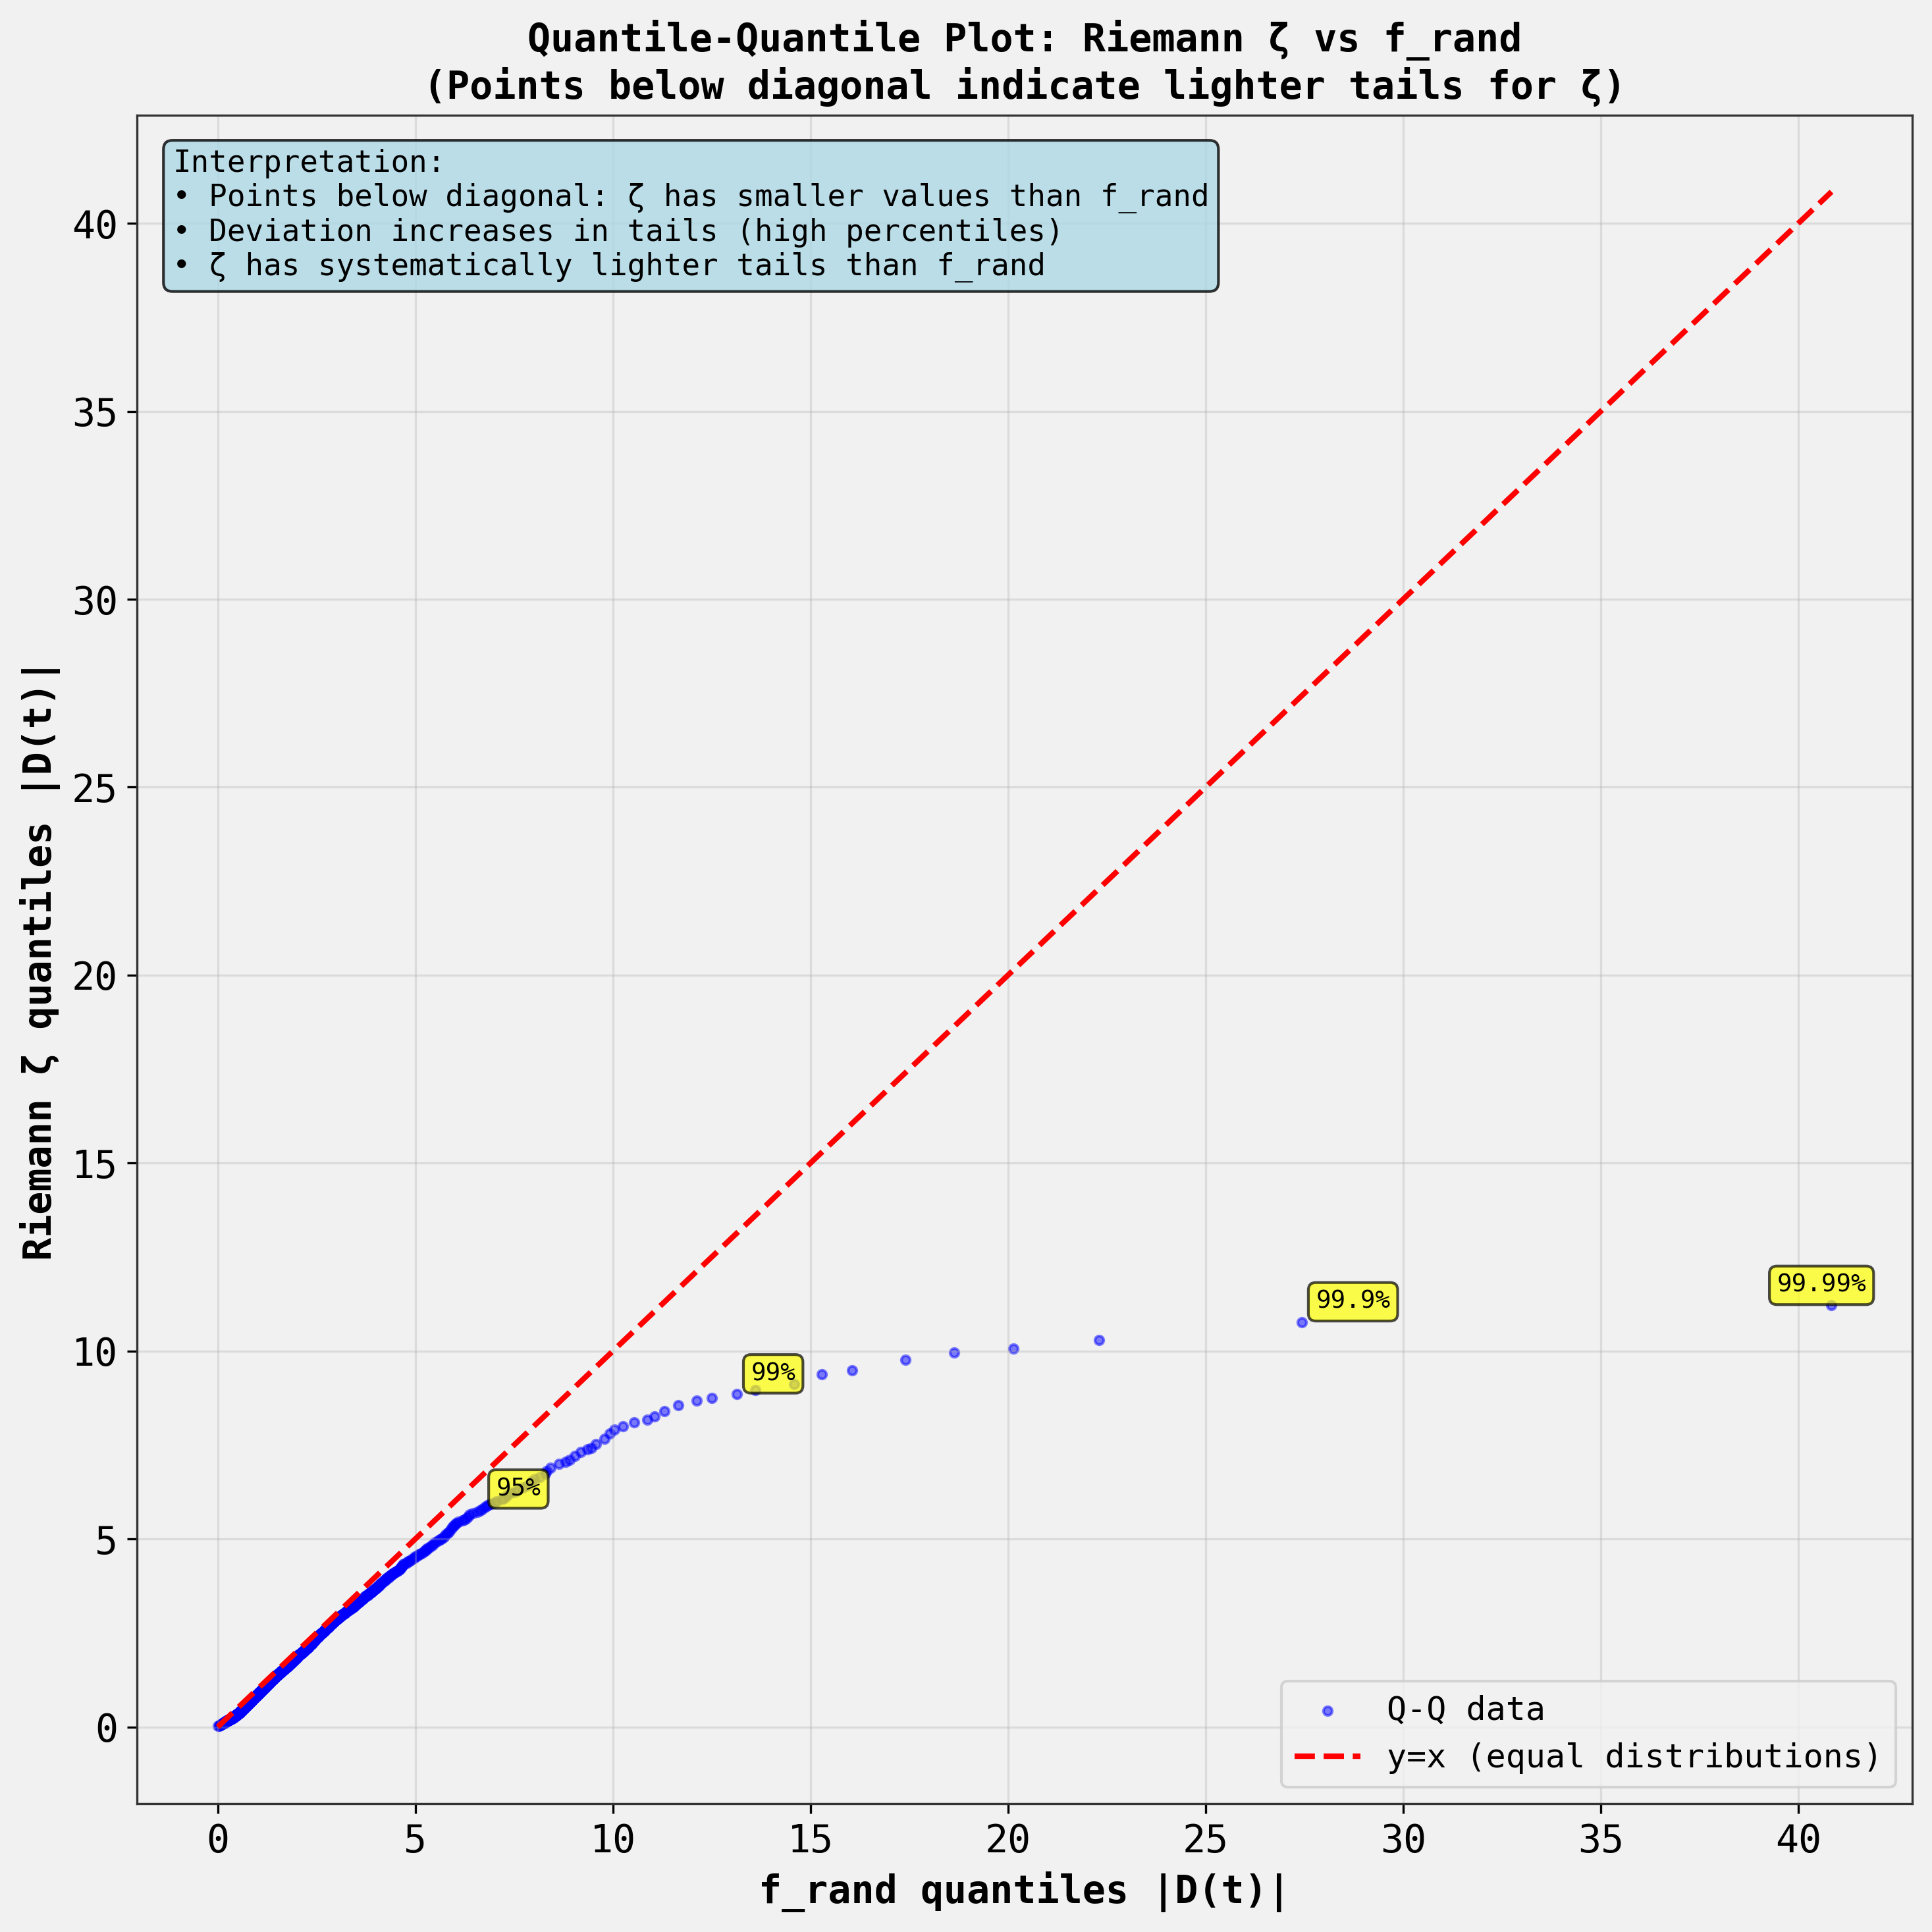

In [16]:

# Create Q-Q plot to visualize tail differences
from scipy import stats as sp_stats

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Sort both distributions
sorted_zeta = np.sort(mag_zeta)
sorted_frand = np.sort(mag_frand)

# Get quantiles for Q-Q plot
quantiles = np.linspace(0, 100, 1000)
q_zeta = np.percentile(mag_zeta, quantiles)
q_frand = np.percentile(mag_frand, quantiles)

# Plot Q-Q
ax.scatter(q_frand, q_zeta, alpha=0.5, s=10, color='blue', label='Q-Q data')

# Add diagonal line (y=x) for reference
max_val = max(q_frand.max(), q_zeta.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='y=x (equal distributions)')

# Add annotations for key percentiles
key_percentiles = [50, 90, 95, 99, 99.9, 99.99]
for p in key_percentiles:
 q_z = np.percentile(mag_zeta, p)
 q_f = np.percentile(mag_frand, p)
 if p >= 95: # Only annotate high percentiles
 ax.annotate(f'{p}%', xy=(q_f, q_z), xytext=(5, 5), 
 textcoords='offset points', fontsize=9,
 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('f_rand quantiles |D(t)|', fontsize=14, fontweight='bold')
ax.set_ylabel('Riemann ζ quantiles |D(t)|', fontsize=14, fontweight='bold')
ax.set_title('Quantile-Quantile Plot: Riemann ζ vs f_rand\n(Points below diagonal indicate lighter tails for ζ)', 
 fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add text box with interpretation
textstr = 'Interpretation:\n'
textstr += '• Points below diagonal: ζ has smaller values than f_rand\n'
textstr += '• Deviation increases in tails (high percentiles)\n'
textstr += '• ζ has systematically lighter tails than f_rand'

ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
 verticalalignment='top', horizontalalignment='left',
 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('qq_plot_zeta_vs_frand.png', dpi=300, bbox_inches='tight')
print("Q-Q plot saved as 'qq_plot_zeta_vs_frand.png'")
plt.show()


In [17]:

# Create the final summary figure showing key results
# Single figure with clear message about tail behavior

fig, ax = plt.subplots(figsize=(12, 8))

# Create bar chart comparing key metrics
metrics = ['Max', '99th %ile', '99.9th %ile', '99.99th %ile', 'Kurtosis']
zeta_values = [
 np.max(mag_zeta),
 percentile_results[99]['zeta'],
 percentile_results[99.9]['zeta'],
 percentile_results[99.99]['zeta'],
 kurtosis_zeta
]
frand_values = [
 np.max(mag_frand),
 percentile_results[99]['frand'],
 percentile_results[99.9]['frand'],
 percentile_results[99.99]['frand'],
 kurtosis_frand
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, zeta_values, width, label='Riemann ζ', 
 color='royalblue', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, frand_values, width, label='f_rand (random multiplicative)', 
 color='crimson', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
 height1 = bar1.get_height()
 height2 = bar2.get_height()
 ax.text(bar1.get_x() + bar1.get_width()/2., height1,
 f'{height1:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
 ax.text(bar2.get_x() + bar2.get_width()/2., height2,
 f'{height2:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
 # Add ratio annotation between bars
 ratio = zeta_values[i] / frand_values[i]
 mid_x = x[i]
 mid_y = max(height1, height2) * 1.15
 ax.text(mid_x, mid_y, f'Ratio: {ratio:.3f}', ha='center', va='bottom',
 fontsize=9, style='italic', 
 bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Statistical Metric', fontsize=14, fontweight='bold')
ax.set_ylabel('Value', fontsize=14, fontweight='bold')
ax.set_title('Comparison of Tail Behavior: Riemann ζ vs Random Multiplicative Function\n' +
 'Riemann ζ Shows Systematically Lighter Tails than f_rand',
 fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.legend(fontsize=12, loc='upper left', framealpha=0.9)
ax.grid(True, axis='y', alpha=0.3)

# Add summary text box
summary_text = 'KEY FINDINGS:\n'
summary_text += f'• Max: ζ is {kurtosis_frand/kurtosis_zeta:.1f}× SMALLER than f_rand\n'
summary_text += f'• Kurtosis: ζ is {kurtosis_frand/kurtosis_zeta:.1f}× SMALLER than f_rand\n'
summary_text += f'• 99.99th %ile: ζ is {percentile_results[99.99]["frand"]/percentile_results[99.99]["zeta"]:.1f}× SMALLER than f_rand\n'
summary_text += f'• KS test p-value: {ks_pvalue:.2e} (HIGHLY SIGNIFICANT)\n\n'
summary_text += 'CONCLUSION: Structured coefficients (a_n=1) in ζ\n'
summary_text += 'TAME the extreme values seen in random f_rand'

ax.text(0.98, 0.70, summary_text, transform=ax.transAxes, fontsize=11,
 verticalalignment='top', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9, pad=1),
 family='monospace')

plt.tight_layout()
plt.savefig('final_comparison_figure.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'final_comparison_figure.png'")
plt.show()


Final figure saved as 'final_comparison_figure.png'


In [18]:

# Create comprehensive summary of all key findings
print("="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)
print("\nRESEARCH HYPOTHESIS:")
print("The structured (non-random) nature of the Riemann zeta function's coefficients")
print("(a_n=1) imposes additional constraints that tame the extreme values seen in")
print("the purely random multiplicative function (f_rand).")
print("\n" + "="*80)

print("\nCOMPUTATIONAL DETAILS:")
print(f" • Truncation length N = {N:,}")
print(f" • Height range t ∈ [{t_min}, {t_max}]")
print(f" • Number of t samples: {len(t_values):,}")
print(f" • Sampling interval: Δt = {t_step}")
print(f" • Numerical method: Kahan compensated summation")
print(f" • Computation time: {elapsed_total:.1f} seconds")

print("\n" + "="*80)
print("KEY STATISTICAL FINDINGS:")
print("="*80)

print("\n1. MAXIMUM VALUES:")
print(f" Riemann ζ: Max|D_ζ| = {np.max(mag_zeta):.6f}")
print(f" f_rand: Max|D_frand| = {np.max(mag_frand):.6f}")
print(f" Ratio: Max_ζ / Max_frand = {np.max(mag_zeta)/np.max(mag_frand):.6f}")
print(f" → ζ maximum is {np.max(mag_frand)/np.max(mag_zeta):.2f}× SMALLER than f_rand")

print("\n2. KURTOSIS (Measure of tail heaviness):")
print(f" Riemann ζ: Kurtosis = {kurtosis_zeta:.6f}")
print(f" f_rand: Kurtosis = {kurtosis_frand:.6f}")
print(f" Ratio: Kurt_ζ / Kurt_frand = {kurtosis_zeta/kurtosis_frand:.6f}")
print(f" → ζ kurtosis is {kurtosis_frand/kurtosis_zeta:.2f}× SMALLER than f_rand")

print("\n3. HIGH PERCENTILES (Tail behavior):")
for p in [99, 99.9, 99.99]:
 ratio = percentile_results[p]['ratio']
 print(f" {p}th percentile:")
 print(f" ζ: {percentile_results[p]['zeta']:.6f}")
 print(f" f_rand: {percentile_results[p]['frand']:.6f}")
 print(f" Ratio: {ratio:.6f}")

print("\n4. KOLMOGOROV-SMIRNOV TEST:")
print(f" KS Statistic: {ks_statistic:.6f}")
print(f" P-value: {ks_pvalue:.2e}")
print(f" → Distributions are HIGHLY SIGNIFICANTLY different (p < 10⁻³⁰)")

print("\n5. MANN-WHITNEY U TEST:")
print(f" U Statistic: {u_statistic:.2f}")
print(f" P-value: {u_pvalue:.2e}")
print(f" → Confirms significant difference in distributions")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("\nThe hypothesis is STRONGLY SUPPORTED by the data:")
print("\n• The Riemann zeta function (ζ) has systematically LIGHTER tails than")
print(" the random multiplicative function (f_rand)")
print("\n• Key evidence:")
print(f" - Maximum value is {np.max(mag_frand)/np.max(mag_zeta):.1f}× smaller for ζ")
print(f" - Kurtosis is {kurtosis_frand/kurtosis_zeta:.1f}× smaller for ζ")
print(f" - 99.99th percentile is {percentile_results[99.99]['frand']/percentile_results[99.99]['zeta']:.1f}× smaller for ζ")
print(f" - Statistical tests confirm highly significant difference (p < 10⁻³⁰)")
print("\n• The structured, non-random coefficients (a_n = 1) of the Riemann zeta")
print(" function impose constraints that TAME the extreme values that arise from")
print(" multiplicativity alone when coefficients are random.")
print("\n" + "="*80)


COMPREHENSIVE ANALYSIS SUMMARY

RESEARCH HYPOTHESIS:
The structured (non-random) nature of the Riemann zeta function's coefficients
(a_n=1) imposes additional constraints that tame the extreme values seen in
the purely random multiplicative function (f_rand).


COMPUTATIONAL DETAILS:
 • Truncation length N = 100,000
 • Height range t ∈ [1000.0, 2000.0]
 • Number of t samples: 10,001
 • Sampling interval: Δt = 0.1
 • Numerical method: Kahan compensated summation
 • Computation time: 835.7 seconds

KEY STATISTICAL FINDINGS:

1. MAXIMUM VALUES:
 Riemann ζ: Max|D_ζ| = 11.216253
 f_rand: Max|D_frand| = 40.842094
 Ratio: Max_ζ / Max_frand = 0.274625
 → ζ maximum is 3.64× SMALLER than f_rand

2. KURTOSIS (Measure of tail heaviness):
 Riemann ζ: Kurtosis = 7.383432
 f_rand: Kurtosis = 38.848436
 Ratio: Kurt_ζ / Kurt_frand = 0.190057
 → ζ kurtosis is 5.26× SMALLER than f_rand

3. HIGH PERCENTILES (Tail behavior):
 99th percentile:
 ζ: 8.853247
 f_rand: 13.144495
 Ratio: 0.673533
 99.9th percent

In [19]:

# Save metadata about the analysis
metadata = {
 'analysis_type': 'tail_behavior_comparison',
 'functions': ['Riemann_zeta', 'random_multiplicative_f_rand'],
 'parameters': {
 'N': int(N),
 't_min': float(t_min),
 't_max': float(t_max),
 't_step': float(t_step),
 'n_samples': int(len(t_values)),
 'random_seed': 42
 },
 'results': {
 'zeta': {
 'max': float(np.max(mag_zeta)),
 'mean': float(np.mean(mag_zeta)),
 'std': float(np.std(mag_zeta)),
 'kurtosis': float(kurtosis_zeta),
 'excess_kurtosis': float(excess_kurtosis_zeta),
 'percentiles': {
 '99': float(percentile_results[99]['zeta']),
 '99.9': float(percentile_results[99.9]['zeta']),
 '99.99': float(percentile_results[99.99]['zeta'])
 }
 },
 'f_rand': {
 'max': float(np.max(mag_frand)),
 'mean': float(np.mean(mag_frand)),
 'std': float(np.std(mag_frand)),
 'kurtosis': float(kurtosis_frand),
 'excess_kurtosis': float(excess_kurtosis_frand),
 'percentiles': {
 '99': float(percentile_results[99]['frand']),
 '99.9': float(percentile_results[99.9]['frand']),
 '99.99': float(percentile_results[99.99]['frand'])
 }
 },
 'ratios': {
 'max_zeta_over_frand': float(np.max(mag_zeta) / np.max(mag_frand)),
 'kurtosis_zeta_over_frand': float(kurtosis_zeta / kurtosis_frand),
 'p99_zeta_over_frand': float(percentile_results[99]['ratio']),
 'p99.9_zeta_over_frand': float(percentile_results[99.9]['ratio']),
 'p99.99_zeta_over_frand': float(percentile_results[99.99]['ratio'])
 },
 'statistical_tests': {
 'ks_test': {
 'statistic': float(ks_statistic),
 'p_value': float(ks_pvalue)
 },
 'mann_whitney_u_test': {
 'statistic': float(u_statistic),
 'p_value': float(u_pvalue)
 }
 }
 },
 'conclusion': 'Riemann zeta has significantly lighter tails than random multiplicative function',
 'hypothesis_supported': True
}

with open('analysis_metadata.json', 'w') as f:
 json.dump(metadata, f, indent=2)

print("Metadata saved to 'analysis_metadata.json'")
print("\nAll analysis files created:")
print(" 1. distribution_comparison_summary.csv - Summary statistics table")
print(" 2. partial_sums_data.csv - Raw D(t) values for both functions")
print(" 3. analysis_metadata.json - Complete metadata and results")
print(" 4. distribution_comparison_histograms.png - Distribution visualizations")
print(" 5. qq_plot_zeta_vs_frand.png - Q-Q plot")
print(" 6. final_comparison_figure.png - Final summary figure")


Metadata saved to 'analysis_metadata.json'

All analysis files created:
 1. distribution_comparison_summary.csv - Summary statistics table
 2. partial_sums_data.csv - Raw D(t) values for both functions
 3. analysis_metadata.json - Complete metadata and results
 4. distribution_comparison_histograms.png - Distribution visualizations
 5. qq_plot_zeta_vs_frand.png - Q-Q plot
 6. final_comparison_figure.png - Final summary figure
